# §7 vs §8 `Δ_mean_F1_combo` 符号翻转 — 因子解耦实验

## 研究问题

§7（screen）与 §8（confirm）使用**同一套 CV/F1 协议**，但 §7 dual 上 `Δ_mean_F1_combo` 常为负，§8 Top-15 复验常为全正。要区分：

1. **种子效应**：同一批 combo，换 seed 块后 F1 Δ 符号是否翻转？
2. **选择效应**：同一 seed 块，Top-15（按 §7 `conservative_score`）vs Bottom-15 的 F1 Δ 分布是否不同？
3. **AUC–F1 解耦**：AUC Δ 为正但 F1@combo_t* Δ 为负的比例（`auc_up_f1_down`）是否随 seed 块变化？

## 实验设计（2×3 因子）

| 因子 | 水平 | 说明 |
|------|------|------|
| **Seed block** | `§7_screen` `[42,88,2025]` | 与主 notebook §7 一致 |
| | `§8_confirm` `[7,13,123,256,3141]` | 与主 notebook §8 一致 |
| | `exp_extra` `[17,29,101,271,503,2027]` | 独立种子，零重叠 |
| **Combo set** (Arm B) | Top-15 / Bottom-15 | 均来自 §7 `ablation_dual_summary.csv` |

### Arm A（主实验）：固定 Top-15，跨 3 个 seed block

- 输入：§7 已跑完的 `ablation_dual_summary.csv` 中 Top-15 label
- 输出：`block_sign_summary.csv` — 每块 `Δ_mean_F1_combo > 0` 的 combo 比例
- **若种子是主因**：三块 `f1_combo_pos_rate` 应显著不同，且 §8 块接近主 notebook §8 现象

### Arm B（选择偏差）：固定 `§8_confirm` seeds，Top-15 vs Bottom-15

- **若选择是主因**：Top-15 的 `f1_combo_pos_rate` 应系统性高于 Bottom-15（同 seed 块内）

### Arm C（逐 seed 长表）

- `raw_all_blocks.csv` + `enrich_raw_f1_per_seed` → 每行 model×seed×combo 的 `f1_combo_delta_vs_base`
- 可做 combo×seed_block 热力图、AUC Δ vs F1 Δ 散点

## 协议（与主 notebook §7/§8 一致）

- WalkForward CV + temporal ES；`F1@combo_t*` 为 combo 自有 cal 阈值
- `Δ_mean_F1_combo` = 多种子 `F1@combo_t*` 相对**同块同模型 BASE** 的均值差
- 各 seed block 内 BASE 独立重跑（与 §7/§8 节内相对性一致）

### Arm D（F1 稳定性协议对比）

在 **§8_confirm seeds** 上，CV **只跑一遍**，对缓存 OOF 后处理比较 5 种 F1 协议：

| 协议 | 说明 |
|------|------|
| `combo_argmax` | 现状 `F1@combo_t*`（易抖） |
| `base_shared` | 共用 BASE cal t*（最稳、横向可比） |
| `combo_plateau` | cal 上 F1 plateau，阈靠近 BASE |
| `combo_anchor_base` | 仅在 BASE t*±0.15 内搜 combo 阈 |
| `combo_cal_large` | 更大 cal 段再 argmax |

输出：`arm_d/protocol_stability_summary.csv` — 按 `std_f1_delta_across_seeds` 排序，越小越稳。

## 前置条件

请先跑完主 notebook **§7 exec**（`ABLATION_SCREEN_SEEDS=[42,88,2025]`），生成 `07_ablation/ablation_dual_summary.csv`。

输出目录：`output/experiments/f1_seed_deconfound/`


In [2]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = Path.cwd().resolve()
SRC_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "experiments" else NOTEBOOK_DIR
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import importlib
import experiments.winner_cv_utils as wcu
importlib.reload(wcu)

from experiments.winner_cv_utils import (
    ABLATION_BASELINE_LABEL,
    EXPERIMENT_SEEDS_DEFAULT,
    F1_COMBO_COL,
    MODELS,
    SECTION7_SCREEN_SEEDS,
    SECTION8_CONFIRM_SEEDS,
    USED_SEEDS,
    dual_f1_combo_sign_summary,
    enrich_raw_f1_per_seed,
    find_project_root,
    load_ablation_dataframe,
    load_ablation_extra_map,
    load_section7_bottom_labels,
    load_section7_top_labels,
    F1_PROTOCOL_COLUMNS,
    F1_PROTOCOL_DESCRIPTIONS,
    ablation_dual_from_raw,
    run_ablation_confirm,
    run_ablation_f1_stability_arm,
    run_multi_seed_block_confirm,
    summarize_f1_sign_rates,
)

PROJECT_ROOT = find_project_root(SRC_DIR)
REPORT_DIR = PROJECT_ROOT / "src" / "output" / "final_report_fixed"
OUT_DIR = PROJECT_ROOT / "src" / "output" / "experiments" / "f1_seed_deconfound"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 15
BOTTOM_N = 15
RUN_ARM_A = True
RUN_ARM_B = True
RUN_ARM_D = True
SKIP_IF_EXISTS = False
F1_STABILITY_PROTOCOLS = list(F1_PROTOCOL_COLUMNS.keys())
CLEAR_OLD_RESULTS = False

SEED_BLOCKS_ARM_A = {
    "§7_screen": list(SECTION7_SCREEN_SEEDS),
    "§8_confirm": list(SECTION8_CONFIRM_SEEDS),
    "exp_extra": list(EXPERIMENT_SEEDS_DEFAULT),
}
_seed_conflict = set(EXPERIMENT_SEEDS_DEFAULT) & set(USED_SEEDS)
assert not _seed_conflict, f"实验种子与主 notebook 重叠: {_seed_conflict}"

if CLEAR_OLD_RESULTS:
    for p in OUT_DIR.glob("*"):
        if p.is_file():
            p.unlink()
            print("已删除:", p.name)

print("项目根目录:", PROJECT_ROOT)
print("§7 报告:", REPORT_DIR)
print("输出:", OUT_DIR)
print("已占用种子:", USED_SEEDS)
print("Arm A seed blocks:", {k: v for k, v in SEED_BLOCKS_ARM_A.items()})


项目根目录: /Users/jingyuhe/代码/credit-fraud-dealing-with-imbalanced-datasets-test
§7 报告: /Users/jingyuhe/代码/credit-fraud-dealing-with-imbalanced-datasets-test/src/output/final_report_fixed
输出: /Users/jingyuhe/代码/credit-fraud-dealing-with-imbalanced-datasets-test/src/output/experiments/f1_seed_deconfound
已占用种子: [7, 13, 42, 77, 88, 123, 256, 2025, 2026, 3141]
Arm A seed blocks: {'§7_screen': [42, 88, 2025], '§8_confirm': [7, 13, 123, 256, 3141], 'exp_extra': [17, 29, 101, 271, 503, 2027]}


In [3]:
dual_path = REPORT_DIR / "07_ablation" / "ablation_dual_summary.csv"
specs_path = REPORT_DIR / "07_ablation" / "ablation_combo_specs.csv"

for p in (dual_path, specs_path, REPORT_DIR / "df_features.pkl"):
    if not p.is_file():
        raise FileNotFoundError(f"缺少 {p}，请先跑主 notebook §7 exec")

section7_dual = pd.read_csv(dual_path)
extra_map = load_ablation_extra_map(specs_path)
top_labels = load_section7_top_labels(dual_path, top_n=TOP_N)
bottom_labels = load_section7_bottom_labels(dual_path, bottom_n=BOTTOM_N)
df_fe, BASE_FEATURES = load_ablation_dataframe(REPORT_DIR)

overlap = set(top_labels) & set(bottom_labels)
assert not overlap, f"Top/Bottom 重叠: {overlap}"

n_cv_arm_a = (
    len(top_labels) * len(MODELS) * sum(len(s) for s in SEED_BLOCKS_ARM_A.values())
    + len(MODELS) * sum(len(s) for s in SEED_BLOCKS_ARM_A.values())
)
print(f"Arm A: Top-{len(top_labels)} × {len(MODELS)} 模型 × {sum(len(s) for s in SEED_BLOCKS_ARM_A.values())} seeds")
print(f"预计 CV 次数（含 BASE）: {n_cv_arm_a}")
print(f"\nTop-{TOP_N}（§7 conservative_score）:")
for i, lbl in enumerate(top_labels, 1):
    print(f"  {i:2d}. {lbl}")
print(f"\nBottom-{BOTTOM_N}:")
for i, lbl in enumerate(bottom_labels, 1):
    print(f"  {i:2d}. {lbl}")


Arm A: Top-15 × 2 模型 × 14 seeds
预计 CV 次数（含 BASE）: 448

Top-15（§7 conservative_score）:
   1. IF+Ed[log1p+hours]+A1
   2. IF+Ed[log1p+hours+one_euro+micro+bands]+A_top2(V14+V4)
   3. IF+Ed[bands]
   4. IF+A1
   5. IF+Ed[bands]+A1
   6. IF+Ed[hours+micro+bands]+A1
   7. IF+Ed[micro]+A1
   8. IF+Ed[hours+bands]
   9. IF+Ed[log1p+hours+micro+bands]
  10. IF+Ed[log1p+micro]
  11. IF+Ed[log1p+micro+bands]+A1
  12. IF+Ed[one_euro]+A1
  13. IF+Ed[hours+micro+bands]
  14. IF+Ed[hours+bands]+A1
  15. IF+Ed[one_euro+bands]+A1

Bottom-15:
   1. IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)
   2. IF+Ed[hours+one_euro+micro+bands]+A1
   3. IF
   4. IF+Ed[log1p+hours+one_euro+micro]+A_top2(V14+V4)
   5. IF+Ed[micro+bands]+A_top2(V14+V4)
   6. IF+Ed[log1p+hours+bands]+A_top2(V14+V4)
   7. IF+Ed[hours+one_euro+micro+bands]+A_top2(V14+V4)
   8. IF+Ed[hours+micro+bands]+A_top2(V14+V4)
   9. IF+Ed[one_euro+bands]+A_top2(V14+V4)
  10. IF+Ed[log1p+hours+one_euro+micro+bands]+A1
  11. IF+Ed[log1p+hours+one

## Arm A — 固定 Top-15，跨 seed block 复验

同一批 combo 在 `§7_screen` / `§8_confirm` / `exp_extra` 三块上各跑一遍；每块内 BASE 与 combo 使用相同 seeds。


In [4]:
if RUN_ARM_A:
    raw_a, dual_a, block_summary, sign_detail, per_combo = run_multi_seed_block_confirm(
        df_fe,
        BASE_FEATURES,
        top_labels,
        extra_map,
        SEED_BLOCKS_ARM_A,
        OUT_DIR / "arm_a",
        skip_if_exists=SKIP_IF_EXISTS,
    )
    print("\n=== Arm A: 每 seed block Δ_mean_F1_combo 符号 ===")
    display(block_summary.round(4))
    print("\n=== 逐 seed 行级 F1 Δ 为正比例 ===")
    display(sign_detail.round(4))
else:
    print("RUN_ARM_A=False，跳过")


[1/96] LightGBM seed=42 | 0. 基线（仅 BASE）
[2/96] LightGBM seed=42 | IF+Ed[log1p+hours]+A1
[3/96] LightGBM seed=42 | IF+Ed[log1p+hours+one_euro+micro+bands]+A_top2(V14+V4)
[4/96] LightGBM seed=42 | IF+Ed[bands]
[5/96] LightGBM seed=42 | IF+A1
[6/96] LightGBM seed=42 | IF+Ed[bands]+A1
[7/96] LightGBM seed=42 | IF+Ed[hours+micro+bands]+A1
[8/96] LightGBM seed=42 | IF+Ed[micro]+A1
[9/96] LightGBM seed=42 | IF+Ed[hours+bands]
[10/96] LightGBM seed=42 | IF+Ed[log1p+hours+micro+bands]
[11/96] LightGBM seed=42 | IF+Ed[log1p+micro]
[12/96] LightGBM seed=42 | IF+Ed[log1p+micro+bands]+A1
[13/96] LightGBM seed=42 | IF+Ed[one_euro]+A1
[14/96] LightGBM seed=42 | IF+Ed[hours+micro+bands]
[15/96] LightGBM seed=42 | IF+Ed[hours+bands]+A1
[16/96] LightGBM seed=42 | IF+Ed[one_euro+bands]+A1
[17/96] LightGBM seed=88 | 0. 基线（仅 BASE）
[18/96] LightGBM seed=88 | IF+Ed[log1p+hours]+A1
[19/96] LightGBM seed=88 | IF+Ed[log1p+hours+one_euro+micro+bands]+A_top2(V14+V4)
[20/96] LightGBM seed=88 | IF+Ed[bands]
[21/96]

,seed_block,seeds,n,n_positive,positive_rate,mean_delta_mean_AUC,mean_delta_mean_F1_combo
0,§7_screen,"[42, 88, 2025]",15,0,0.0,0.0020,-0.0165
1,§8_confirm,"[7, 13, 123, 256, 3141]",15,15,1.0,0.0037,0.0112
2,exp_extra,"[17, 29, 101, 271, 503, 2027]",15,9,0.6,0.0028,0.0017



=== 逐 seed 行级 F1 Δ 为正比例 ===


,seed_block,n_rows,n_combos,n_seeds,auc_pos_rate,f1_combo_pos_rate,auc_up_f1_down_rate,mean_delta_AUC,mean_f1_combo_delta
0,exp_extra,180,15,6,0.6722,0.5778,0.2333,0.0028,0.0017
1,§7_screen,90,15,3,0.6222,0.3222,0.3778,0.0020,-0.0165
2,§8_confirm,150,15,5,0.7200,0.6333,0.2800,0.0037,0.0112


## Arm B — 选择偏差：Top-15 vs Bottom-15（固定 §8 seeds）


In [5]:
if RUN_ARM_B:
    arm_b_dir = OUT_DIR / "arm_b"
    arm_b_dir.mkdir(parents=True, exist_ok=True)
    s8_seeds = list(SECTION8_CONFIRM_SEEDS)
    arm_b_results = []

    for cohort, labels in [("top15", top_labels), ("bottom15", bottom_labels)]:
        ckpt = arm_b_dir / f"checkpoint_{cohort}.csv"
        if SKIP_IF_EXISTS and ckpt.is_file():
            raw_b = pd.read_csv(ckpt)
            dual_b = ablation_dual_from_raw(raw_b)
            print(f"[{cohort}] 从 checkpoint 加载")
        else:
            raw_b, _, dual_b = run_ablation_confirm(
                df_fe, BASE_FEATURES, labels, extra_map,
                seeds=s8_seeds, checkpoint_path=ckpt,
            )
        raw_b = enrich_raw_f1_per_seed(raw_b)
        raw_b["cohort"] = cohort
        raw_b.to_csv(arm_b_dir / f"raw_{cohort}.csv", index=False, encoding="utf-8-sig")
        sign = dual_f1_combo_sign_summary(dual_b)
        row_level = summarize_f1_sign_rates(
            raw_b.assign(seed_block="§8_confirm"),
            group_cols=["cohort"],
        )
        arm_b_results.append({
            "cohort": cohort,
            "n_combos": len(labels),
            **sign,
            "row_f1_pos_rate": float(row_level["f1_combo_pos_rate"].iloc[0]),
            "row_auc_up_f1_down_rate": float(row_level["auc_up_f1_down_rate"].iloc[0]),
            "mean_delta_mean_F1_combo": float(dual_b["Δ_mean_F1_combo"].mean()),
        })

    arm_b_summary = pd.DataFrame(arm_b_results)
    arm_b_summary.to_csv(arm_b_dir / "cohort_compare.csv", index=False, encoding="utf-8-sig")
    print("\n=== Arm B: §8 seeds 上 Top vs Bottom ===")
    display(arm_b_summary.round(4))
else:
    print("RUN_ARM_B=False，跳过")


[1/160] LightGBM seed=7 | 0. 基线（仅 BASE）
[2/160] LightGBM seed=7 | IF+Ed[log1p+hours]+A1
[3/160] LightGBM seed=7 | IF+Ed[log1p+hours+one_euro+micro+bands]+A_top2(V14+V4)
[4/160] LightGBM seed=7 | IF+Ed[bands]
[5/160] LightGBM seed=7 | IF+A1
[6/160] LightGBM seed=7 | IF+Ed[bands]+A1
[7/160] LightGBM seed=7 | IF+Ed[hours+micro+bands]+A1
[8/160] LightGBM seed=7 | IF+Ed[micro]+A1
[9/160] LightGBM seed=7 | IF+Ed[hours+bands]
[10/160] LightGBM seed=7 | IF+Ed[log1p+hours+micro+bands]
[11/160] LightGBM seed=7 | IF+Ed[log1p+micro]
[12/160] LightGBM seed=7 | IF+Ed[log1p+micro+bands]+A1
[13/160] LightGBM seed=7 | IF+Ed[one_euro]+A1
[14/160] LightGBM seed=7 | IF+Ed[hours+micro+bands]
[15/160] LightGBM seed=7 | IF+Ed[hours+bands]+A1
[16/160] LightGBM seed=7 | IF+Ed[one_euro+bands]+A1
[17/160] LightGBM seed=13 | 0. 基线（仅 BASE）
[18/160] LightGBM seed=13 | IF+Ed[log1p+hours]+A1
[19/160] LightGBM seed=13 | IF+Ed[log1p+hours+one_euro+micro+bands]+A_top2(V14+V4)
[20/160] LightGBM seed=13 | IF+Ed[bands]
[21

,cohort,n_combos,n,n_positive,positive_rate,row_f1_pos_rate,row_auc_up_f1_down_rate,mean_delta_mean_F1_combo
0,top15,15,15,15,1.0000,0.6333,0.28,0.0112
1,bottom15,15,15,11,0.7333,0.5667,0.26,0.0076


## Arm D — F1@combo 稳定性协议（§8 seeds，OOF 后处理）

同一批 Top-15：**CV 只训一次**，在缓存 OOF 上比较 5 种定阈协议。  
主指标：`std_f1_delta_across_seeds`（跨 seed F1 Δ 标准差，**越小越稳**）。

In [6]:
if RUN_ARM_D:
    arm_d_dir = OUT_DIR / "arm_d"
    print("F1 协议一览：")
    for k, v in F1_PROTOCOL_DESCRIPTIONS.items():
        print(f"  {k}: {v}")

    raw_d, proto_summary, dual_by_proto = run_ablation_f1_stability_arm(
        df_fe,
        BASE_FEATURES,
        top_labels,
        extra_map,
        seeds=list(SECTION8_CONFIRM_SEEDS),
        out_dir=arm_d_dir,
        protocols=F1_STABILITY_PROTOCOLS,
        skip_if_exists=SKIP_IF_EXISTS,
    )
    print("\n=== Arm D: 协议稳定性（按 std_f1_delta 升序）===")
    display(proto_summary.round(4))

    best = proto_summary.iloc[0]
    print(
        f"\n最稳协议: {best['protocol']} "
        f"(std={best['std_f1_delta_across_seeds']:.4f}, "
        f"row_pos_rate={best['row_f1_pos_rate']:.2%})"
    )
else:
    print("RUN_ARM_D=False，跳过")

F1 协议一览：
  combo_argmax: 现状：combo 在 cal 上 argmax F1（易抖）
  base_shared: 共用 BASE cal t*（横向可比，最稳）
  combo_plateau: cal 上 F1≥max−0.02 的 plateau，取最靠近 BASE t* 的阈
  combo_anchor_base: 仅在 BASE t*±0.15 内搜 combo 最优阈
  combo_cal_large: 更大 cal（frac=0.35, fraud≥80）再 argmax

=== Arm D: 协议稳定性（按 std_f1_delta 升序）===


,protocol,description,f1_col,row_f1_pos_rate,mean_f1_delta,std_f1_delta_across_seeds,mean_thr_std_per_combo,combo_dual_pos_rate,mean_combo_dual_f1_delta
1,base_shared,共用 BASE cal t*（横向可比，最稳）,F1@BASE_t*,0.6133,0.0050,0.0159,0.1481,0.8000,0.0050
2,combo_plateau,cal 上 F1≥max−0.02 的 plateau，取最靠近 BASE t* 的阈,F1@combo_plateau,0.6467,0.0068,0.0199,0.1393,0.8000,0.0068
3,combo_anchor_base,仅在 BASE t*±0.15 内搜 combo 最优阈,F1@combo_anchor,0.6533,0.0105,0.0275,0.1230,0.9333,0.0105
4,combo_cal_large,"更大 cal（frac=0.35, fraud≥80）再 argmax",F1@combo_cal_large,0.5000,-0.0029,0.0441,0.1623,0.3333,-0.0029
0,combo_argmax,现状：combo 在 cal 上 argmax F1（易抖）,F1@combo_t*,0.6333,0.0112,0.0464,0.1348,1.0000,0.0112



最稳协议: base_shared (std=0.0159, row_pos_rate=61.33%)


/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/3651512403.py:24: UserWarning: Glyph 36328 (\N{CJK UNIFIED IDEOGRAPH-8DE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/3651512403.py:24: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/3651512403.py:24: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/3651512403.py:24: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/3651512403.py:24: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k9/rjyh

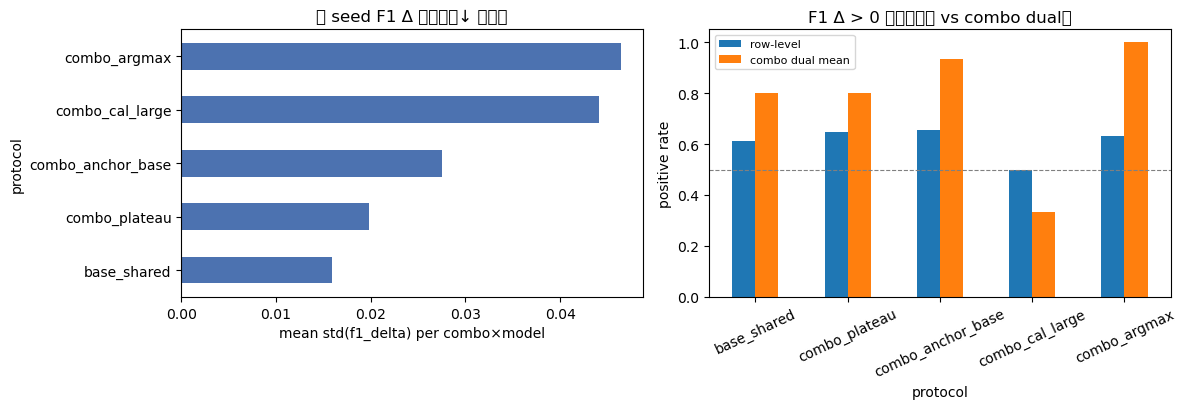

In [7]:
arm_d_dir = OUT_DIR / "arm_d"
proto_path = arm_d_dir / "protocol_stability_summary.csv"
if proto_path.is_file():
    proto_summary = pd.read_csv(proto_path)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

    order = proto_summary.sort_values("std_f1_delta_across_seeds")["protocol"]
    plot_df = proto_summary.set_index("protocol").loc[order]

    plot_df["std_f1_delta_across_seeds"].plot(
        kind="barh", ax=axes[0], color="#4C72B0",
    )
    axes[0].set_title("跨 seed F1 Δ 标准差（↓ 更稳）")
    axes[0].set_xlabel("mean std(f1_delta) per combo×model")

    plot_df[["row_f1_pos_rate", "combo_dual_pos_rate"]].plot(
        kind="bar", ax=axes[1], rot=25,
    )
    axes[1].set_title("F1 Δ > 0 比例（行级 vs combo dual）")
    axes[1].set_ylabel("positive rate")
    axes[1].legend(["row-level", "combo dual mean"], fontsize=8)
    axes[1].axhline(0.5, ls="--", c="gray", lw=0.8)

    plt.tight_layout()
    fig.savefig(OUT_DIR / "arm_d_protocol_stability.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("请先运行 Arm D")

## Arm C — 分析与解读

读取 Arm A 输出，对比主 notebook §7/§8 已保存 dual（若存在）。


In [8]:
arm_a_dir = OUT_DIR / "arm_a"
raw_all = pd.read_csv(arm_a_dir / "raw_all_blocks.csv")
dual_all = pd.read_csv(arm_a_dir / "dual_all_blocks.csv")
enriched = enrich_raw_f1_per_seed(raw_all)
enriched.to_csv(arm_a_dir / "raw_enriched_per_seed.csv", index=False, encoding="utf-8-sig")

# 与主 notebook §7/§8 dual 对照（节内 Δ，非横向绝对值）
ref_rows = []
s7_ref = section7_dual[~section7_dual["特征组合"].astype(str).str.startswith("0.")].head(TOP_N)
ref_rows.append({
    "source": "main_§7_dual",
    "n": len(s7_ref),
    "f1_pos_rate": float((s7_ref["Δ_mean_F1_combo"] > 0).mean()) if "Δ_mean_F1_combo" in s7_ref.columns else np.nan,
    "mean_F1_delta": float(s7_ref["Δ_mean_F1_combo"].mean()) if "Δ_mean_F1_combo" in s7_ref.columns else np.nan,
})
s8_path = REPORT_DIR / "07_ablation" / "ablation_top15_confirm_dual.csv"
if s8_path.is_file():
    s8_ref = pd.read_csv(s8_path)
    ref_rows.append({
        "source": "main_§8_confirm_dual",
        "n": len(s8_ref),
        "f1_pos_rate": float((s8_ref["Δ_mean_F1_combo"] > 0).mean()),
        "mean_F1_delta": float(s8_ref["Δ_mean_F1_combo"].mean()),
    })
for block in dual_all["seed_block"].unique():
    d = dual_all[dual_all["seed_block"] == block]
    ref_rows.append({
        "source": f"exp_arm_a_{block}",
        "n": len(d),
        "f1_pos_rate": float((d["Δ_mean_F1_combo"] > 0).mean()),
        "mean_F1_delta": float(d["Δ_mean_F1_combo"].mean()),
    })
ref_compare = pd.DataFrame(ref_rows)
ref_compare.to_csv(OUT_DIR / "interpretation_ref_compare.csv", index=False, encoding="utf-8-sig")
print("=== 主 notebook vs 本实验 Arm A（Top-15 Δ_mean_F1_combo 符号率）===")
display(ref_compare.round(4))


=== 主 notebook vs 本实验 Arm A（Top-15 Δ_mean_F1_combo 符号率）===


,source,n,f1_pos_rate,mean_F1_delta
0,main_§7_dual,15,0.0,-0.0165
1,main_§8_confirm_dual,15,1.0,0.0112
2,exp_arm_a_§7_screen,15,0.0,-0.0165
3,exp_arm_a_§8_confirm,15,1.0,0.0112
4,exp_arm_a_exp_extra,15,0.6,0.0017


/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/2636884632.py:31: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/2636884632.py:31: UserWarning: Glyph 32423 (\N{CJK UNIFIED IDEOGRAPH-7EA7}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/2636884632.py:31: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/2636884632.py:31: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/2636884632.py:31: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/i

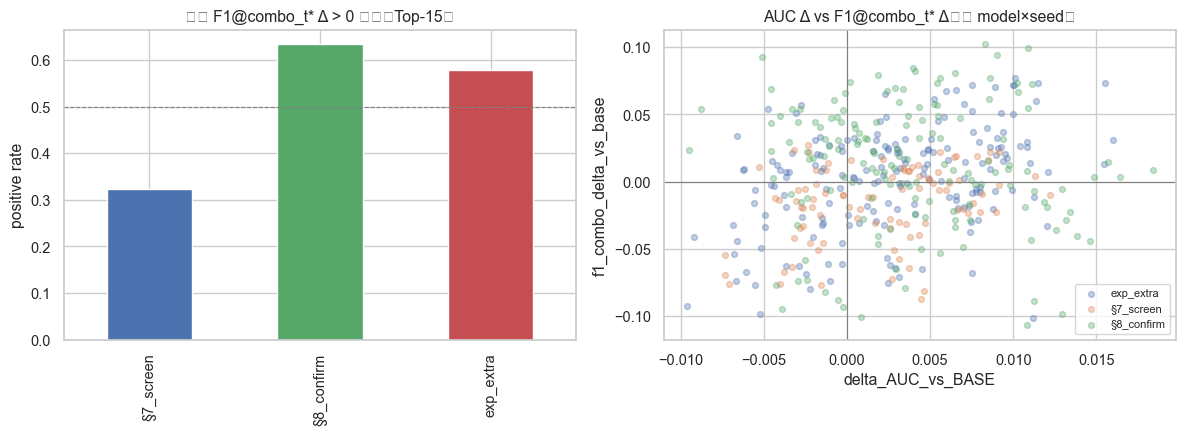

/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/2636884632.py:45: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/2636884632.py:45: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/2636884632.py:45: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/2636884632.py:45: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_16821/2636884632.py:45: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/i

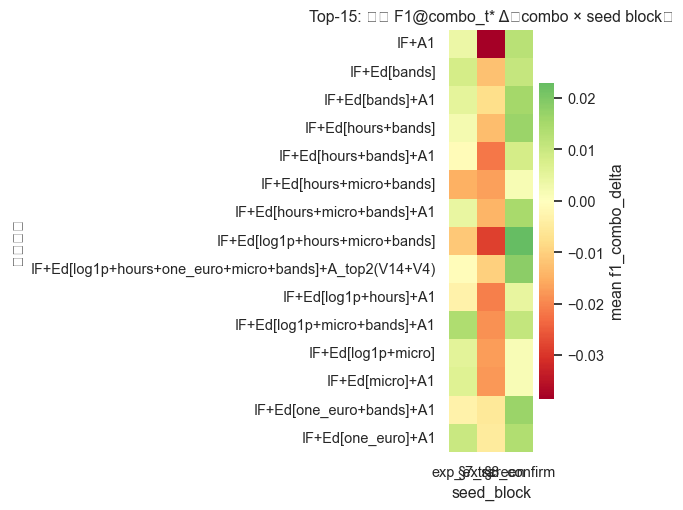

In [9]:
sns.set_theme(style="whitegrid", font_scale=0.95)
combos_only = enriched[~enriched["特征组合"].astype(str).str.startswith("0.")]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1) seed block × F1 Δ 为正比例（行级 model×seed）
rate = (
    combos_only.groupby("seed_block")["f1_combo_delta_positive"]
    .mean()
    .reindex(["§7_screen", "§8_confirm", "exp_extra"])
)
rate.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#55A868", "#C44E52"])
axes[0].set_title("行级 F1@combo_t* Δ > 0 比例（Top-15）")
axes[0].set_ylabel("positive rate")
axes[0].set_xlabel("")
axes[0].axhline(0.5, ls="--", c="gray", lw=0.8)

# 2) AUC Δ vs F1 Δ 散点（按 seed block 着色）
for block, sub in combos_only.groupby("seed_block"):
    axes[1].scatter(
        sub["delta_AUC_vs_BASE"], sub["f1_combo_delta_vs_base"],
        alpha=0.35, s=18, label=block,
    )
axes[1].axhline(0, c="gray", lw=0.8)
axes[1].axvline(0, c="gray", lw=0.8)
axes[1].set_xlabel("delta_AUC_vs_BASE")
axes[1].set_ylabel("f1_combo_delta_vs_base")
axes[1].set_title("AUC Δ vs F1@combo_t* Δ（逐 model×seed）")
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUT_DIR / "arm_a_sign_rates.png", dpi=150, bbox_inches="tight")
plt.show()

# combo × seed_block 热力图（均值 F1 Δ）
pivot = (
    combos_only.groupby(["特征组合", "seed_block"])["f1_combo_delta_vs_base"]
    .mean()
    .unstack("seed_block")
)
if not pivot.empty:
    fig2, ax2 = plt.subplots(figsize=(6, max(4, 0.35 * len(pivot))))
    sns.heatmap(pivot, cmap="RdYlGn", center=0, ax=ax2, cbar_kws={"label": "mean f1_combo_delta"})
    ax2.set_title("Top-15: 均值 F1@combo_t* Δ（combo × seed block）")
    plt.tight_layout()
    fig2.savefig(OUT_DIR / "arm_a_combo_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()


## 如何读结果

| 观测 | 解读 |
|------|------|
| Arm A 三块 `f1_combo_pos_rate` 差异大，且 `§8_confirm` ≈ 主 §8 | **种子效应**为主 |
| 三块接近，但 Top（Arm A/B）远高于 Bottom（Arm B） | **选择效应**为主 |
| `auc_up_f1_down_rate` 各块均高 | AUC 与 F1@combo_t* 结构性解耦 |
| Arm D：`base_shared` / `combo_anchor` std 最低 | 定阈应锚定 BASE 或收窄搜索带 |
| Arm D：`combo_argmax` std 最高但 dual_pos_rate 未必最低 | 抖动大 ≠ 均值一定差，不宜单独作排序主指标 |

### 落地建议（主 notebook）

1. **排序/筛选**：继续以 AUC + `conservative_score` 为主；F1 用 `F1@BASE_t*` 作辅助稳定性列。
2. **若要看 combo F1 潜力**：优先 `combo_plateau` 或 `combo_anchor_base`，而非裸 `F1@combo_t*`。
3. **业务阈固定场景**：只信 `F1@BASE_t*`；`F1@combo_t*` 仅作上界参考。

> 各 seed block 的 Δ 均相对**该块内**多种子 BASE，不要跨块比较 F1 绝对值。
